# this is not correct

In [11]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stim
import sinter

REPO = "/Users/ycx0376/hbm/lattice_surgery/decoder-bench"
sys.path.insert(0, REPO + "/decoder_bench/ls_ckt_gen")

from circuit_zzxx import circuit as ls_circuit


# ============================================================
# basic helpers
# ============================================================

def coord_union(mapping):
    return (
        set(mapping["data_coords"])
        | set(mapping["x_measure_coords"])
        | set(mapping["z_measure_coords"])
    )


def coord_xy(coord):
    if isinstance(coord, complex):
        return int(round(coord.real)), int(round(coord.imag))
    if isinstance(coord, (tuple, list)) and len(coord) >= 2:
        return int(round(coord[0])), int(round(coord[1]))
    raise TypeError(f"Unsupported coord format: {coord}")


def set_patch_noise(sim, coords, p):
    for coord in coords:
        for gate in sim.gates_1Q:
            sim.profile[coord]["error"][gate] = p
        for gate in sim.gates_2Q:
            sim.profile[coord]["error"][gate] = p
        for gate in sim.measures:
            sim.profile[coord]["error"][gate] = p


def midpoint(a, b):
    return int(round((a + b) / 2))


# ============================================================
# sparse square layout geometry from DATA qubits
# ============================================================

def get_data_rows(data_coords):
    """
    Returns:
      ys: sorted list of data-qubit row coordinates
      row_dict: map y -> sorted x coordinates of data qubits in that row
    """
    row_dict = {}
    for c in data_coords:
        x, y = coord_xy(c)
        row_dict.setdefault(y, []).append(x)

    for y in row_dict:
        row_dict[y] = sorted(row_dict[y])

    ys = sorted(row_dict.keys())
    return ys, row_dict


def shared_2_hot_xy_from_data_coords(data_coords):
    """
    1 shared/hot qubit every 2 data qubits, between them in x direction.
    If odd count, place one below the last data qubit, unless last row.
    """
    ys, row_dict = get_data_rows(data_coords)
    hot_xy = set()

    if not ys:
        return hot_xy

    for r, y in enumerate(ys):
        xs = row_dict[y]
        n = len(xs)

        n_hot = n // 2
        remainder = n % 2

        if n_hot > 0:
            step = n / n_hot
            for i in range(n_hot):
                idx = int(i * step)
                if idx < len(xs) - 1:
                    x_mid = midpoint(xs[idx], xs[idx + 1])
                    hot_xy.add((x_mid, y))

        # odd leftover -> one below last qubit, unless last data row
        if remainder == 1 and r < len(ys) - 1:
            y_next = ys[r + 1]
            x_last = xs[-1]
            hot_xy.add((x_last, midpoint(y, y_next)))

    return hot_xy


def shared_4_hot_xy_from_data_coords(data_coords):
    """
    1 shared/hot qubit for each 2x2 block of data qubits.
    Center of 4 data qubits.
    """
    ys, row_dict = get_data_rows(data_coords)
    hot_xy = set()

    # process row pairs: (row0,row1), (row2,row3), ...
    for r in range(0, len(ys) - 1, 2):
        y_top = ys[r]
        y_bot = ys[r + 1]
        xs = row_dict[y_top]

        i = 0
        while i + 1 < len(xs):
            x1, x2 = xs[i], xs[i + 1]
            if x2 - x1 >= 2:
                hot_xy.add((midpoint(x1, x2), midpoint(y_top, y_bot)))
                i += 2
            else:
                i += 1

    return hot_xy


def shared_8_hot_xy_from_data_coords(data_coords):
    """
    1 shared/hot qubit for each 2x4 block of data qubits.
    Center of 8 data qubits.
    """
    ys, row_dict = get_data_rows(data_coords)
    hot_xy = set()

    # process row pairs: (row0,row1), (row2,row3), ...
    for r in range(0, len(ys) - 1, 2):
        y_top = ys[r]
        y_bot = ys[r + 1]
        xs = row_dict[y_top]

        i = 0
        while i + 3 < len(xs):
            x1, x4 = xs[i], xs[i + 3]
            hot_xy.add((midpoint(x1, x4), midpoint(y_top, y_bot)))
            i += 4

    return hot_xy


# ============================================================
# choose hot qubits in RIGHT patch
# ============================================================

def select_hot_right_patch_coords(right_patch_mapping, mode):
    """
    Returns actual coordinates in the RIGHT patch that should get 10p.

    mode:
      - "symmetric" : no hot qubits
      - "shared_2"
      - "shared_4"
      - "shared_8"
      - "full_right" : all qubits in right patch hot
    """
    right_all_coords = coord_union(right_patch_mapping)
    right_data_coords = set(right_patch_mapping["data_coords"])

    if mode == "symmetric":
        return set()

    if mode == "full_right":
        return set(right_all_coords)

    if mode == "shared_2":
        hot_xy = shared_2_hot_xy_from_data_coords(right_data_coords)
    elif mode == "shared_4":
        hot_xy = shared_4_hot_xy_from_data_coords(right_data_coords)
    elif mode == "shared_8":
        hot_xy = shared_8_hot_xy_from_data_coords(right_data_coords)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # Map actual patch coordinates by (x,y)
    xy_to_coord = {coord_xy(c): c for c in right_all_coords}

    hot_coords = set()
    missing_xy = []

    for xy in hot_xy:
        if xy in xy_to_coord:
            hot_coords.add(xy_to_coord[xy])
        else:
            missing_xy.append(xy)

    if missing_xy:
        print(f"[warn] mode={mode}: {len(missing_xy)} requested hot positions not found in right patch coords.")
        print("first few missing:", missing_xy[:10])

    return hot_coords


# ============================================================
# build stim circuit
# ============================================================

def build_ls_stim_circuit(distance, p, mode="symmetric", basis="Z", factor=10.0):
    sim = ls_circuit(
        distance=distance,
        num_patches_x=20,
        num_patches_y=20,
        spacing=1,
        disable_noise=False,
        fixed_t1=25,
        fixed_t2=40,
        fixed_cnot_latency=50,
        fixed_measure_latency=600,
        fixed_cnot_noise=0.0,
        fixed_measure_noise=0.0,
        rounds_per_op=distance,
        idle_multiplier=1,
        basis=basis,
        ls_basis=basis,
        merge=True,
    )

    left = sim.map_qubit(0)
    right = sim.map_qubit(1)
    merged = sim.merge({0: left, 1: right})

    left_coords = coord_union(left)
    right_coords = coord_union(right)
    bridge_coords = coord_union(merged) - left_coords - right_coords

    # baseline p everywhere
    set_patch_noise(sim, left_coords, p)
    set_patch_noise(sim, right_coords, p)
    set_patch_noise(sim, bridge_coords, p)

    # overwrite only the selected right-patch hot coords to factor*p
    hot_right_coords = select_hot_right_patch_coords(right, mode)
    set_patch_noise(sim, hot_right_coords, factor * p)

    sim.from_string("qreg q[2];")

    return stim.Circuit(sim.ckt), hot_right_coords, right


# ============================================================
# make sinter tasks
# ============================================================

def make_tasks(
    distances=(3, 5, 7, 9, 11),
    p_values=(1e-4, 3e-4, 7e-4, 1e-3),
    basis="Z",
    modes=("symmetric", "shared_2", "shared_4", "shared_8"),
    factor=10.0,
):
    tasks = []

    for mode in modes:
        for p in p_values:
            for d in distances:
                circuit, hot_right_coords, _ = build_ls_stim_circuit(
                    distance=d,
                    p=p,
                    mode=mode,
                    basis=basis,
                    factor=factor,
                )

                tasks.append(
                    sinter.Task(
                        circuit=circuit,
                        json_metadata={
                            "mode": mode,
                            "distance": d,
                            "p": p,
                            "factor": factor,
                            "num_hot_right_coords": len(hot_right_coords),
                        },
                    )
                )

    return tasks


# ============================================================
# collect results
# ============================================================

def collect_df(tasks, max_shots=20_000, max_errors=400, num_workers=1):
    stats = sinter.collect(
        tasks=tasks,
        decoders=["pymatching"],
        max_shots=max_shots,
        max_errors=max_errors,
        num_workers=num_workers,
    )

    rows = []
    for stat in stats:
        md = stat.json_metadata
        rows.append({
            "mode": md["mode"],
            "distance": md["distance"],
            "p": md["p"],
            "factor": md["factor"],
            "num_hot_right_coords": md["num_hot_right_coords"],
            "shots": stat.shots,
            "errors": stat.errors,
            "ler": stat.errors / stat.shots if stat.shots else np.nan,
        })

    return pd.DataFrame(rows).sort_values(["mode", "distance", "p"]).reset_index(drop=True)


# ============================================================
# plotting
# ============================================================

def plot_ler(df, mode, title):
    sub = df[df["mode"] == mode].copy()
    pivot = sub.pivot(index="p", columns="distance", values="ler").sort_index()

    plt.figure(figsize=(6, 4))
    for d in pivot.columns:
        plt.plot(pivot.index, pivot[d], marker="o", label=f"d={d}")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("base physical error rate p")
    plt.ylabel("logical error rate")
    plt.title(title)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pivot


def plot_all_modes(df, modes=("symmetric", "shared_2", "shared_4", "shared_8")):
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    axes = axes.flatten()

    for ax, mode in zip(axes, modes):
        sub = df[df["mode"] == mode].copy()
        pivot = sub.pivot(index="p", columns="distance", values="ler").sort_index()

        for d in pivot.columns:
            ax.plot(pivot.index, pivot[d], marker="o", label=f"d={d}")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("p")
        ax.set_ylabel("LER")
        ax.set_title(mode)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# sanity / debug helpers
# ============================================================

def inspect_hot_coords(distance=5, p=1e-3, basis="Z", factor=10.0):
    print("Inspecting hot coordinates")
    for mode in ["symmetric", "shared_2", "shared_4", "shared_8", "full_right"]:
        _, hot, right = build_ls_stim_circuit(
            distance=distance,
            p=p,
            mode=mode,
            basis=basis,
            factor=factor,
        )
        hot_sorted = sorted([coord_xy(c) for c in hot])
        print(f"{mode:10s} num_hot = {len(hot_sorted)} sample = {hot_sorted[:10]}")


def plot_patch_geometry(distance=5, p=1e-3, mode="shared_4", basis="Z", factor=10.0):
    _, hot, right = build_ls_stim_circuit(
        distance=distance,
        p=p,
        mode=mode,
        basis=basis,
        factor=factor,
    )

    data_xy = np.array([coord_xy(c) for c in right["data_coords"]])
    x_xy = np.array([coord_xy(c) for c in right["x_measure_coords"]])
    z_xy = np.array([coord_xy(c) for c in right["z_measure_coords"]])
    hot_xy = np.array([coord_xy(c) for c in hot]) if len(hot) > 0 else np.empty((0, 2))

    plt.figure(figsize=(6, 6))
    if len(data_xy):
        plt.scatter(data_xy[:, 0], data_xy[:, 1], label="data")
    if len(x_xy):
        plt.scatter(x_xy[:, 0], x_xy[:, 1], label="X meas")
    if len(z_xy):
        plt.scatter(z_xy[:, 0], z_xy[:, 1], label="Z meas")
    if len(hot_xy):
        plt.scatter(hot_xy[:, 0], hot_xy[:, 1], s=120, marker="x", label="hot (10p)")

    plt.gca().set_aspect("equal")
    plt.title(f"{mode}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Inspecting hot coordinates
symmetric  num_hot = 0 sample = []
[warn] mode=shared_2: 14 requested hot positions not found in right patch coords.
first few missing: [(18, 1), (18, 7), (14, 1), (14, 7), (21, 6), (18, 3), (21, 2), (18, 9), (14, 3), (14, 9)]
shared_2   num_hot = 0 sample = []
shared_4   num_hot = 4 sample = [(14, 2), (14, 6), (18, 2), (18, 6)]
shared_8   num_hot = 2 sample = [(16, 2), (16, 6)]
full_right num_hot = 49 sample = [(12, 4), (12, 8), (13, 1), (13, 3), (13, 5), (13, 7), (13, 9), (14, 0), (14, 2), (14, 4)]
[warn] mode=shared_2: 14 requested hot positions not found in right patch coords.
first few missing: [(18, 1), (18, 7), (14, 1), (14, 7), (21, 6), (18, 3), (21, 2), (18, 9), (14, 3), (14, 9)]


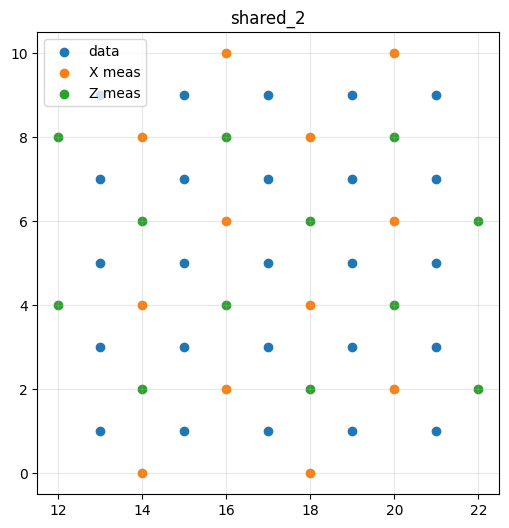

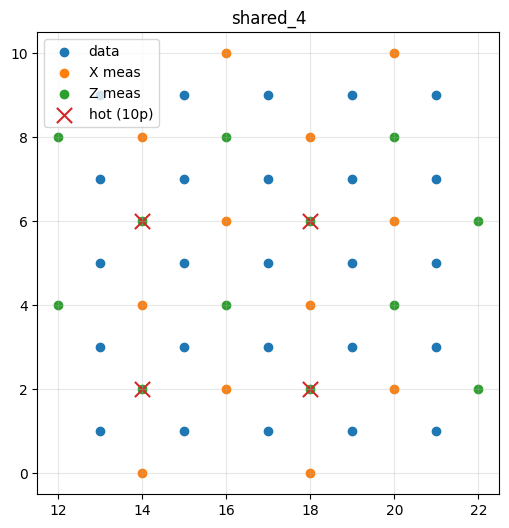

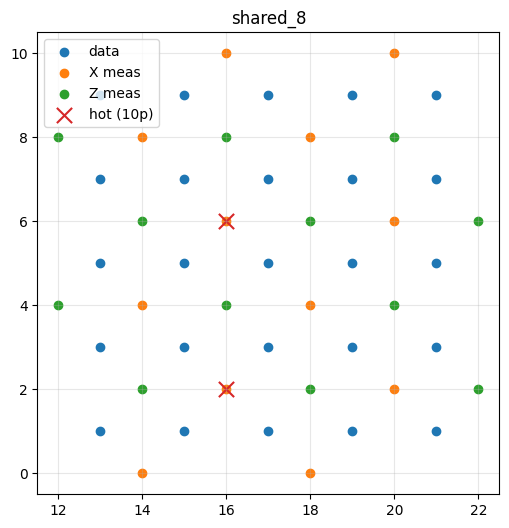

In [12]:
# ============================================================
# run
# ============================================================

distances = [3, 5, 7, 9, 11]
p_values = [1e-4, 3e-4, 7e-4, 1e-3, 3e-3, 7e-3, 1e-2]
modes = ["symmetric", "shared_2", "shared_4", "shared_8"]

# First check that the hot positions are where you expect
inspect_hot_coords(distance=5, p=1e-3)
plot_patch_geometry(distance=5, p=1e-3, mode="shared_2")
plot_patch_geometry(distance=5, p=1e-3, mode="shared_4")
plot_patch_geometry(distance=5, p=1e-3, mode="shared_8")

# tasks = make_tasks(
#     distances=distances,
#     p_values=p_values,
#     basis="Z",
#     modes=modes,
#     factor=10.0,
# )

# df = collect_df(
#     tasks,
#     max_shots=10_000,
#     max_errors=300,
#     num_workers=1,
# )

# print(df.head())
# df.to_csv("ls_shared_modes_results.csv", index=False)

# plot_ler(df, "symmetric", "Symmetric: all qubits use p")
# plot_ler(df, "shared_2", "Right patch hot subset: shared_2")
# plot_ler(df, "shared_4", "Right patch hot subset: shared_4")
# plot_ler(df, "shared_8", "Right patch hot subset: shared_8")

# plot_all_modes(df, modes=modes)